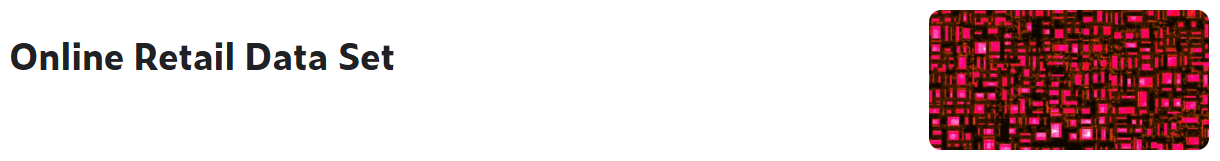

* https://www.kaggle.com/datasets/vijayuv/onlineretail

In [1]:
from sklearn import set_config
set_config(display="text")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings('ignore')


#----------차트 속성 (한글처리/그리드)
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False



#----------문제/답 분리
from sklearn.model_selection import train_test_split 


#----------군집모델
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_samples, silhouette_score


#----------분류모델
from sklearn.linear_model import LogisticRegression   #선형모델 
from sklearn.ensemble import RandomForestClassifier   #트리모델


#----------모델결합(Ensembles)
from sklearn.ensemble import VotingClassifier, VotingRegressor   #앙상블


#----------평가 매트릭스
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, precision_recall_curve, average_precision_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, classification_report


#----------교차검증
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, cross_val_score, cross_validate


#----------인코딩(글자->숫자)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


#----------정규화(스케일링)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler 


#----------차원 축소
from sklearn.decomposition import PCA 

# **[1] Data Load**

<pre>
InvoiceNo    :  영수증 번호 (고유 주문 번호, 'C'로 시작하면 취소)
StockCode    :  상품 코드 (고유 상품 번호)
Description  :  상품명 (상품 이름 및 설명)
Quantity     :  주문 수량 (취소/반품 시 음수)
InvoiceDate  :  주문 일시 (거래가 발생한 날짜와 시간)
UnitPrice    :  상품 단가 (개당 가격)
CustomerID   :  고객 ID (고유 회원 번호)
Country      :  주문 국가 (고객 거주 국가)

* 최근 방문 여부
* 구매 빈도(재구매 횟수)
* 구매 금액/수량 (시간별/국가별)
* 총 매출 추이

<font color=blue> **<마케팅분석 RFM>** </font>
* Recency (최근성) : 마지막 구매/활동 시점이 **얼마나 최근**인가    - InvoiceDate
* Frequency (빈도) : 일정 기간 동안 **얼마나 자주** 구매/행동했는가 - InvoiceNo, StockCode
* Monetary (금액)  : 고객이 **얼마나 많은 금액**을 지출했는가       - UnitPrice * Quantity
* → <u> 휴면고객/이탈고객의 구매를 이끌어내기 위함

In [3]:
df = pd.read_csv("../../Datas/#online/OnlineRetail.csv", parse_dates=['InvoiceDate'], encoding='ISO-8859-1')
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB


# **[2] 전처리&가공**

* 컬럼 소문자 변경
* 파생피쳐 : Price = Quantity*UnitPrice
* 주요 타겟 : Country == 'United Kingdom'
* 분석 제외
   * 비회원 : CustomerID 결측
   * 취소건 : InvoiceNo ('C'로 시작하면 취소)
   * 국가 : 영국 뺀 나머지
   * 상품번호 : StockCode
   * 상품설명 : Description

## 컬럼 소문자 변경 

In [5]:
df.columns = df.columns.str.lower()

In [6]:
df.head(2)

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 파생피쳐 : Price

In [7]:
df['price'] = df['quantity'] * df['unitprice']

In [8]:
df.head(2)

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


#### price 0인 고객은 빈도를 위해 삭제 X

In [9]:
df[df['price']==0].groupby('customerid')['customerid'].count().sort_values(ascending=False)

customerid
13081.0    4
14646.0    4
12415.0    2
13985.0    2
14911.0    2
12444.0    1
12431.0    1
12507.0    1
12603.0    1
12748.0    1
12647.0    1
13014.0    1
12446.0    1
12457.0    1
12437.0    1
13256.0    1
13239.0    1
13113.0    1
14110.0    1
14410.0    1
15107.0    1
15581.0    1
15602.0    1
15804.0    1
16133.0    1
16406.0    1
16560.0    1
16818.0    1
17560.0    1
17667.0    1
18059.0    1
Name: customerid, dtype: int64

## 분석제외
* 취소건 : InvoiceNo ('C'로 시작하면 취소)
  * <font color=red> <b> 주의!!!!! : 원주문 건 데이터가 남아있는지, 부분취소인지, 취소건의 금액이 -로 되어있는지 등 사전 확인 필요!!!!
* 비회원 : CustomerID 결측
* 국가 : 영국 뺀 나머지

#### 취소건 : InvoiceNo ('C'로 시작하면 취소)
* 취소건과 quantity가 -인 데이터가 수량이 맞는지 먼저 확인

In [10]:
df[ df['invoiceno'].str[:1] == 'C' ].shape

(9288, 9)

In [11]:
df[ df['quantity']<0].shape

(10624, 9)

In [12]:
df = df.iloc[df['quantity']>=0, :]

#### 상품 : StockCode, Description

In [13]:
df = df.drop(columns=['stockcode', 'description'])

#### quantity, unitprice 삭제

In [14]:
df = df.drop(columns=['quantity', 'unitprice'])

#### 참고) for/if 사용

```python
dfcp = df.copy()

del_idx_list = []

for idx, row in dfcp.iterrows():

    if (pd.isna(row['customerid']) or
        str(row['invoiceno']).startswith('C') or
        row['country'] != 'United Kingdom'):

        del_idx_list.append(idx)

dfcp = dfcp.drop(del_idx_list)

dfcp.head()

#### 비회원  : CustomerID 결측

In [15]:
df = df.dropna(subset=['customerid'])

#### 국가 : 영국 뺀 나머지

In [16]:
df = df[ df['country'] == 'United Kingdom' ]

----------------------------------------------

In [17]:
df.head()

,invoiceno,invoicedate,customerid,country,price
0,536365,2010-12-01 08:26:00,17850.0,United Kingdom,15.30
1,536365,2010-12-01 08:26:00,17850.0,United Kingdom,20.34
2,536365,2010-12-01 08:26:00,17850.0,United Kingdom,22.00
3,536365,2010-12-01 08:26:00,17850.0,United Kingdom,20.34
4,536365,2010-12-01 08:26:00,17850.0,United Kingdom,20.34


## 데이터 수집 기간

In [18]:
df['invoicedate'].min(), df['invoicedate'].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:49:00'))

In [19]:
df['diff'] = df['invoicedate'].max() - df['invoicedate']

In [20]:
df['diff'] = df['diff'].apply(lambda d : d.days +1)    #-------max-max=0 방지 위해 +1

In [21]:
df.head(2)

,invoiceno,invoicedate,customerid,country,price,diff
0,536365,2010-12-01 08:26:00,17850.0,United Kingdom,15.30,374
1,536365,2010-12-01 08:26:00,17850.0,United Kingdom,20.34,374


## 불필요한 컬럼 삭제

* 영국 기준으로 다 삭제했기 때문에 country 불필요
* price/diff 파생피쳐 만들었기 때문에 나머지 불필요

In [22]:
df = df.drop(columns=['country', 'invoicedate'])

In [23]:
# ---------- RFM!
df = df.rename(columns={"diff":"R", "invoiceno":"F", "price":"M"})

## 최종 분석 데이터

In [24]:
df.head(2)

,F,customerid,M,R
0,536365,17850.0,15.30,374
1,536365,17850.0,20.34,374


# **[3] user별 RFM 분석**
* R : max
* F : count
* M : sum
* groupby customerid

In [25]:
df.groupby('customerid')['R'].max()

customerid
12346.0    326
12747.0    369
12748.0    374
12749.0    213
12820.0    327
          ... 
18280.0    278
18281.0    181
18282.0    126
18283.0    337
18287.0    202
Name: R, Length: 3921, dtype: int64

In [26]:
df.groupby('customerid')['F'].count()

customerid
12346.0       1
12747.0     103
12748.0    4596
12749.0     199
12820.0      59
           ... 
18280.0      10
18281.0       7
18282.0      12
18283.0     756
18287.0      70
Name: F, Length: 3921, dtype: int64

In [27]:
df.groupby('customerid')['M'].sum()

customerid
12346.0    77183.60
12747.0     4196.01
12748.0    33719.73
12749.0     4090.88
12820.0      942.34
             ...   
18280.0      180.60
18281.0       80.82
18282.0      178.05
18283.0     2094.88
18287.0     1837.28
Name: M, Length: 3921, dtype: float64

In [28]:
rfm_df = df.groupby('customerid').agg({'R': 'max', 'F': 'count', 'M': 'sum'})
rfm_df.head()

,R,F,M
customerid,,,
12346.0,326,1,77183.60
12747.0,369,103,4196.01
12748.0,374,4596,33719.73
12749.0,213,199,4090.88
12820.0,327,59,942.34


In [29]:
rfm_df.info()

<class 'pandas.DataFrame'>
Index: 3921 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   R       3921 non-null   int64  
 1   F       3921 non-null   int64  
 2   M       3921 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 122.5 KB


# **[4] 군집모델**

## 표준화

```python
ss = StandardScaler()

ss.fit(rfm_df)
scale_res = ss.fit_transform(rfm_df)
scale_res[:3]

## PCA

```python
#-----------2차로 줄인 투영값
pca = PCA(n_components=2 , random_state=1234)
pca_res = pca.fit_transform(scale_res)
pca_res[:3]

```python
#-----------설명력 확인
primnt( f"개별 PC 설명력 : {pca.explained_variance_ratio_}" )
print( f"PCA 전체 설명력 : {pca.explained_variance_ratio_.sum():.3f}" )

## 최종 데이터

```python
pca_df = pd.DataFrame(pca_res, columns=["pc1", "pc2"])
pca_df.head(2)

## KMeans

### K값 튜닝_적정K값 찾기 : inertia 엘보차트

In [30]:
def MY_SPCA_CHART(rfm_df) : 
    # ---------------- 표준화 & PCA  -----------------
    ss =  StandardScaler()
    ss.fit(rfm_df)
    scale_res = ss.transform(rfm_df)
    
    pca = PCA(n_components=2, random_state=1234)
    pca_res = pca.fit_transform(scale_res)
    print( f"각각의 PC 설명력 : {pca.explained_variance_ratio_}" )
    print( f"PCA 전체 설명력 : {pca.explained_variance_ratio_.sum():.3f}" )
    
    pca_df = pd.DataFrame(pca_res, columns=['pc1','pc2'])
    pca_df.head(2)
    
    inertia_list = []
    k_list = [2, 3, 4, 5]
    
    # 총 5개의 subplot 생성 (4개는 K별 산점도, 마지막 1개는 엘보우 차트)
    fig, axes = plt.subplots(1, len(k_list) + 1, figsize=(20, 5))
    
    for i, MY_K in enumerate(k_list):
        kmodel = KMeans(n_clusters=MY_K, random_state=1234)
        
        # 1. 학습 및 예측
        # (이미 pc1, pc2만 있는 데이터프레임이므로 변수명만 넣어주셔도 안전합니다)
        pred_label = kmodel.fit_predict(pca_df[['pc1','pc2']])
        pca_df['pred_label'] = pred_label
        rfm_df[f'pred_label_{MY_K}'] = pred_label 

        sscore = silhouette_score(pca_df[['pc1','pc2']], pred_label)
        print(f"{MY_K} {sscore:.4f}")
        
        sns.scatterplot(data=pca_df, x="pc1", y="pc2", hue="pred_label", ax=axes[i], legend=False)
        axes[i].set_title(f"K = {MY_K}")
        
        #중심점(CH)
        ch = kmodel.cluster_centers_
        axes[i].scatter(ch[:, 0], ch[:, 1], marker="X", s=200, 
                        color="red", edgecolor="black", linewidth=1.5, label="Center")
    
        inertia_list.append(kmodel.inertia_)
        print(inertia_list)
    
    # ----------- 엘보차트 -------------
    axes[-1].plot([2,3,4,5], inertia_list, marker='o', color='purple', linestyle='--')
    axes[-1].set_title("엘보차트(적정K값)")
    
    plt.tight_layout()
    plt.show()

    return rfm_df

각각의 PC 설명력 : [0.48814527 0.28905088]
PCA 전체 설명력 : 0.777
2 0.5304
[5912.709856434884]
3 0.5546
[5912.709856434884, 2905.3716307735513]
4 0.5786
[5912.709856434884, 2905.3716307735513, 1942.9929216935357]
5 0.5543
[5912.709856434884, 2905.3716307735513, 1942.9929216935357, 1490.1386809795656]


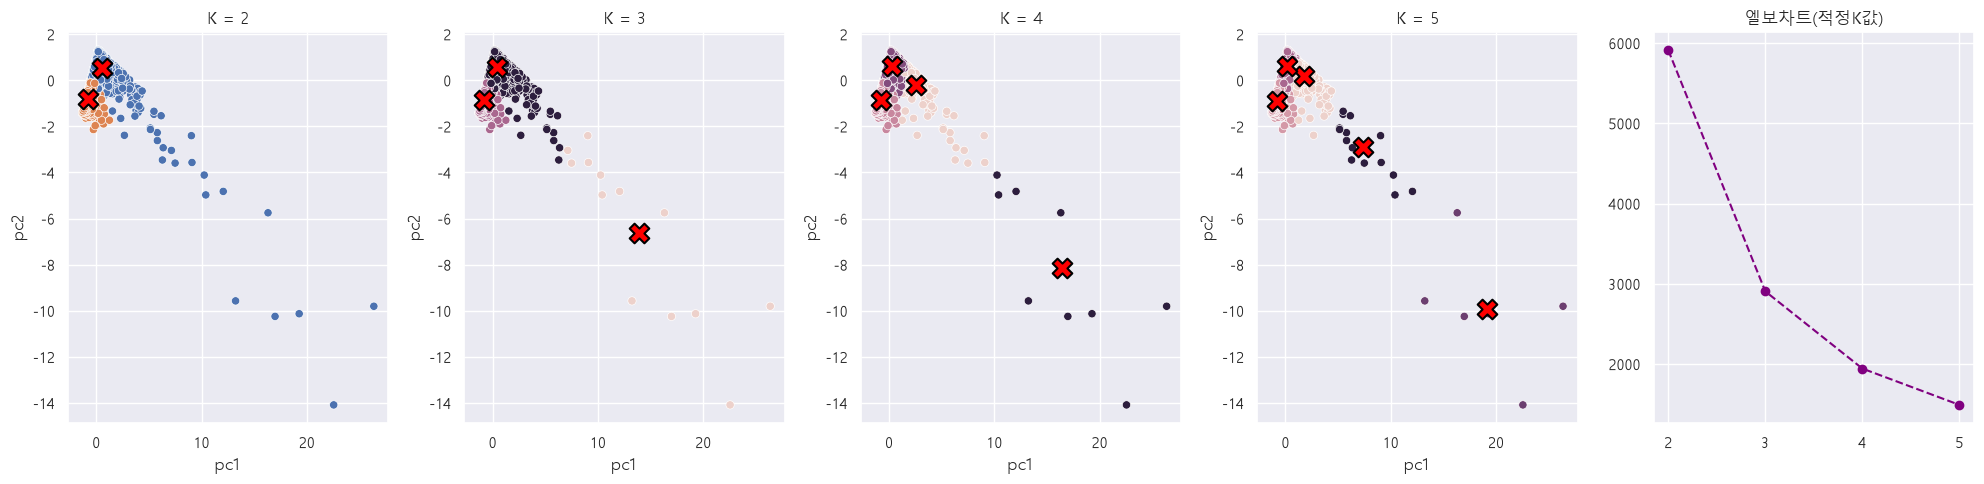

,R,F,M,pred_label_2,pred_label_3,pred_label_4,pred_label_5
customerid,,,,,,,
12346.0,326,1,77183.60,0,2,0,4
12747.0,369,103,4196.01,0,2,2,2


In [31]:
res_df = MY_SPCA_CHART(rfm_df[['R','F','M']])
res_df.head(2)

### mycode

```python

inertia_list = []

for my_k in range(2, 11):
    kmodel = KMeans(n_clusters=my_k, random_state=1234)
    kmodel.fit(scale_res)
    pred_label = kmodel.predict(scale_res)

    inertia_list.append(kmodel.inertia_)

```python
plt.figure(figsize=(8, 3))

plt.plot(range(2, 11), inertia_list, marker='o')

plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('엘보차트')

plt.xticks(range(2, 11))
plt.grid()

plt.show()

## 로그변환

In [32]:
rfm_df.head(2)

,R,F,M
customerid,,,
12346.0,326,1,77183.60
12747.0,369,103,4196.01


In [33]:
res = np.log1p(rfm_df)
res.head(2)

,R,F,M
customerid,,,
12346.0,5.789960,0.693147,11.253955
12747.0,5.913503,4.644391,8.342128


각각의 PC 설명력 : [0.6551519  0.26525569]
PCA 전체 설명력 : 0.920
2 0.4190
[5735.336810527449]
3 0.4427
[5735.336810527449, 3671.001671516112]
4 0.3985
[5735.336810527449, 3671.001671516112, 2738.696919994652]
5 0.4020
[5735.336810527449, 3671.001671516112, 2738.696919994652, 2263.84339813693]


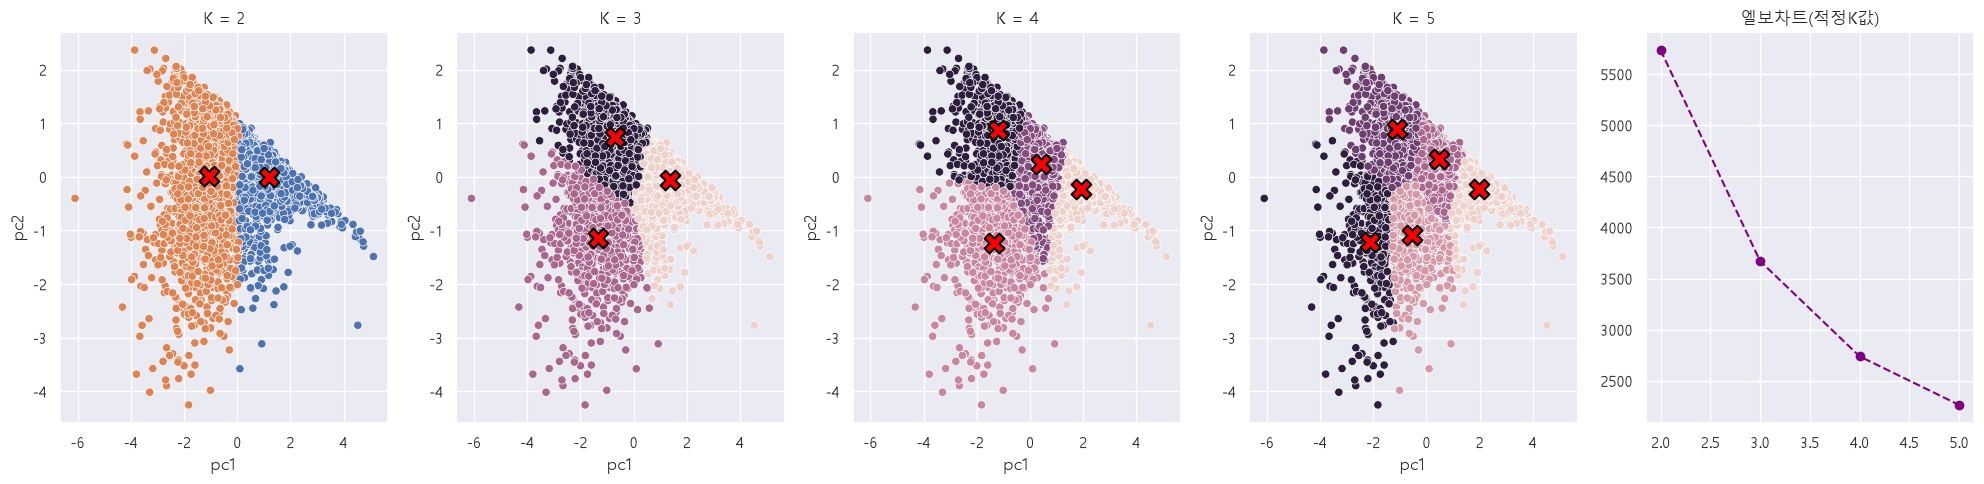

,R,F,M,pred_label_2,pred_label_3,pred_label_4,pred_label_5
customerid,,,,,,,
12346.0,5.789960,0.693147,11.253955,0,0,2,2
12747.0,5.913503,4.644391,8.342128,0,0,0,0


In [34]:
res_df = MY_SPCA_CHART(res)
res_df.head(2)

## **군집분석**

In [36]:
res_df[['R','F','M']] = np.expm1(res_df[['R','F','M']])

In [37]:
res_df.head(2)

,R,F,M,pred_label_2,pred_label_3,pred_label_4,pred_label_5
customerid,,,,,,,
12346.0,326.0,1.0,77183.60,0,0,2,2
12747.0,369.0,103.0,4196.01,0,0,0,0


In [39]:
res = res_df.groupby('pred_label_3').agg({'R':'max', 'F':'count', 'M':'sum'})
res

,R,F,M
pred_label_3,,,
0,374.0,1584,6268733.261
1,113.0,866,420713.991
2,374.0,1471,618944.302


In [40]:
res = res_df.groupby('pred_label_4').agg({'R':'max', 'F':'count', 'M':'sum'})
res

,R,F,M
pred_label_4,,,
0,374.0,854,5242242.431
1,112.0,785,372203.581
2,374.0,1352,1450263.812
3,374.0,930,243681.730


In [41]:
res = res_df.groupby('pred_label_5').agg({'R':'max', 'F':'count', 'M':'sum'})
res

,R,F,M
pred_label_5,,,
0,374.0,810,5145488.261
1,135.0,552,436614.571
2,374.0,1237,1378631.302
3,374.0,937,257322.080
4,84.0,385,90335.340


### K=3 vs K=4 vs K=5 비교
* K=3 : 고액 고객 겹쳐 집중대상 모호
* K=4 : 돈 많이 쓰는 집단/ 자주 오던 집단 명확히 갈림, 맞춤형 마케팅 가능
* K=5 : K5에 이르러서야 막 들어온 그룹4와 지갑 열기 시작한 주력 고객이 분리됨
 ------------------------------------------
    * K=3, K=4까지는 살아있는 활성 고객이 단 하나(R=112~113)로 뭉뚱그려져 있어서 마케팅이 획일적일 수밖에 없었습니다.
    * K=5에 이르러서야 막 들어온 새싹 고객(그룹 4)과 지갑을 열기 시작한 주력 고객(그룹 1)이 분리되었습니다.
    * 따라서 마케팅 예산은 그룹 1(성장 유지)과 그룹 4(안착 유도)에 집중 투입하고, 휴면층 중에서는 오직 그룹 0(초고액 VIP)의 복귀에만 선별적 예산을 쓰는 것이 가장 효율적입니다.

In [ ]:
sdfsdf

## silhouette_score

In [ ]:
silhouette_list = []

for my_k in range(2, 11):

    model = KMeans(n_clusters=my_k, random_state=1234, n_init=10)

    labels = model.fit_predict(scale_res)

    score = silhouette_score(scale_res, labels)

    silhouette_list.append(score)

    print(f'K={my_k}, 실루엣 스코어={score:.4f}')

### scatter

In [ ]:
plt.figure(figsize=(8, 3))

plt.scatter(
    range(2, 11),
    silhouette_list,
    s=100
)

plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by K')

plt.xticks(range(2, 11))
plt.grid()

plt.show()

## K = 5
* K=5, 실루엣 스코어=0.5570

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=1234)

rfm_df['cluster'] = kmeans.fit_predict(scale_res)

### 군집별 고객 수

In [ ]:
rfm_df['cluster'].value_counts().sort_index()

### 군집별 RFM 평균

In [ ]:
rfm_df.groupby('cluster')[['R', 'F', 'M']].mean().round(2)

### k값 4/5 비교

In [ ]:
for k in [4, 5]:

    model = KMeans(n_clusters=k, random_state=1234, n_init=10)

    labels = model.fit_predict(scale_res)

    print(f'K={k}')
    print(pd.Series(labels).value_counts().sort_index())
    print()